# 09k — EGFR–MOL00583: repliche CUDA e confronto con 09j
Tre rami stocastici da 10 ns, con velocità e semi nuovi e 100 ps NPT di riequilibrazione ciascuno. Partono tutti dallo **stesso snapshot finale di 09h (1 ns)**: non sono tre preparazioni strutturali indipendenti. Parametri e microstato neutro restano quelli di 09h. Nessuna nuova parametrizzazione.

MOL00583: **TIER_1_PRIMARY_COMPUTATIONAL_LEAD**, non validato sperimentalmente. Nessuna stima di ΔG o entropia. Durate uguali migliorano il confronto con 09j, ma non assicurano convergenza.

Prima: RUN_MD=True, FAST_TEST_MODE=True (una replica, 50 ps). Dopo verifica: FAST_TEST_MODE=False (tre repliche da 10 ns). Riavviare kernel ed eseguire tutto. Nessun fallback CPU automatico. Output nuovi per ogni esecuzione; non rieseguire soltanto la cella MD dopo interruzioni. Checkpoint conservati, resume automatico non implementato.

In [1]:
from pathlib import Path
import json,hashlib,time,sys,platform,gc
from datetime import datetime,timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openmm as mm
from openmm import app,unit
import mdtraj as mt
PEARL_ROOT=Path(r'C:\Users\Roberto\PEARL')
SOURCE=PEARL_ROOT/'outputs/pipeline_5_pharmacophore_09h_mol00583_md/20260912T174721_843455Z_seed20260912'
FREE_RUN=PEARL_ROOT/'outputs/pipeline_5_09j_free_ligand/20260914T085625_154393Z'
OUTPUT_BASE=PEARL_ROOT/'outputs/pipeline_5_09k_bound_replicates'
RUN_MD=True
FAST_TEST_MODE=False
SEEDS=[20260931] if FAST_TEST_MODE else [20260931,20260932,20260933]
EQUIL_PS=10.0 if FAST_TEST_MODE else 100.0
PRODUCTION_PS=50.0 if FAST_TEST_MODE else 10000.0
FRAME_PS=1.0 if FAST_TEST_MODE else 10.0
PLATFORM='CUDA'
PLATFORM_PROPERTIES={'DeviceIndex':'0','Precision':'mixed'}
DISCARD_FRACTION=0.2
EXPECTED_SHA256={'states/production_system.xml': '512f12ff002b25a97a54a8bb78cf2c3527869011f8ba03360cfb6829357fc45d', 'states/production_integrator.xml': 'c8931563c5a025b070dedcabc366f468aa4a8f671bf317dcabf843b925a6ad59', 'states/production_final.xml': '223e5e76f341b87533769a76be9b05c8c06b3d34ef5cf9fd9fd2f380cdee639d', 'structures/solvated.pdb': '9b79a90eeea35fccb6381a728fa2bff3a5bf26edc5db67d6b35b9fe98828a006', 'structures/solute_reference_09f.pdb': '0b628e31e4626fde9bee66028e5322abd6c465bd3dcab50167f4ad40a398ccd0'}
def require(ok,msg):
    if not ok:raise RuntimeError(msg)
def dump(p,obj):Path(p).write_text(json.dumps(obj,indent=2,default=str),encoding='utf-8')
def sha(p):
    h=hashlib.sha256()
    with Path(p).open('rb') as f:
        for b in iter(lambda:f.read(1024*1024),b''):h.update(b)
    return h.hexdigest()
for name,digest in EXPECTED_SHA256.items():
    require((SOURCE/name).is_file(),f'Input assente: {SOURCE/name}')
    require(sha(SOURCE/name)==digest,f'Input modificato: {name}')
require((FREE_RUN/'free_bound_metrics.csv').is_file(),f'Output 09j assente: {FREE_RUN}')
free_summary=json.loads((FREE_RUN/'09j_summary.json').read_text())
require(free_summary['technical_qc_pass'] and free_summary['mode']=='exploratory_production','09j deve essere produzione con QC superato.')
require(free_summary['replicas']==3 and free_summary['production_ps_per_replica']==10000,'Attese tre repliche libere da 10 ns.')
require(free_summary['microstate']=='neutral_same_as_09h','Microstato incompatibile.')
print('Repliche:',len(SEEDS),'| produzione per replica:',PRODUCTION_PS,'ps',flush=True)
require(RUN_MD,'Preflight completato. Impostare RUN_MD=True.')


Repliche: 3 | produzione per replica: 10000.0 ps


In [2]:
pdb=app.PDBFile(str(SOURCE/'structures/solvated.pdb'))
ref=mt.load(str(SOURCE/'structures/solute_reference_09f.pdb'))
nsolute=ref.n_atoms
lig=ref.topology.select('resname LIG')
heavy=ref.topology.select('resname LIG and element != H')
ca=ref.topology.select('protein and name CA')
protein=ref.topology.select('protein and element != H')
require(len(heavy)>0 and len(ca)>3,'Selezione LIG/proteina vuota.')
require([a.name for a in list(pdb.topology.atoms())[:nsolute]]==[a.name for a in ref.topology.atoms],'Ordine soluto incompatibile.')
initial=mm.XmlSerializer.deserialize((SOURCE/'states/production_final.xml').read_text())
RUN=OUTPUT_BASE/datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
RUN.mkdir(parents=True,exist_ok=False)
provenance={'status':'started','candidate':'MOL00583','tier':'TIER_1_PRIMARY_COMPUTATIONAL_LEAD',
 'experimentally_validated':False,'source':str(SOURCE),'source_sha256':EXPECTED_SHA256,
 'free_source':str(FREE_RUN),'free_metrics_sha256':sha(FREE_RUN/'free_bound_metrics.csv'),
 'OpenMM':mm.__version__,'python':sys.version,'host':platform.platform(),'seeds':SEEDS,
 'production_ps':PRODUCTION_PS,'equil_ps':EQUIL_PS,'frame_ps':FRAME_PS,'discard_fraction':DISCARD_FRACTION,
 'shared_start':'09h final 1 ns; stochastic branches, not independent preparations','test':FAST_TEST_MODE}
dump(RUN/'provenance.json',provenance)
def snapshot(sim,folder,label):
    state=sim.context.getState(getPositions=True,getVelocities=True,getEnergy=True,getParameters=True)
    require(np.isfinite(state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)),'Energia non finita.')
    require(np.isfinite(state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)).all(),'Coordinate non finite.')
    (folder/(label+'.xml')).write_text(mm.XmlSerializer.serialize(state))
    sim.saveCheckpoint(str(folder/(label+'.chk')))
    return state
replica_dirs=[]


## Simulazione
Si mantengono integratore, timestep, temperatura, pressione e forze originali. Nuove velocità a temperatura target; riequilibrazione NPT senza restrizioni. DCD del soluto ogni 10 ps nel run lungo, log e checkpoint periodici. Gli XML e la topologia sorgente permettono successivi endpoint energetici sul soluto; il DCD completo dell'acqua non viene salvato.

In [3]:
try:
    for r,seed in enumerate(SEEDS,1):
        folder=RUN/f'replica_{r:02d}_seed{seed}';folder.mkdir();replica_dirs.append(folder)
        system=mm.XmlSerializer.deserialize((SOURCE/'states/production_system.xml').read_text())
        it=mm.XmlSerializer.deserialize((SOURCE/'states/production_integrator.xml').read_text())
        require(isinstance(it,mm.LangevinMiddleIntegrator),'Integratore inatteso.')
        require(system.getNumParticles()==pdb.topology.getNumAtoms(),'Topologia incompatibile.')
        require(not any(isinstance(f,mm.CustomExternalForce) for f in system.getForces()),'Restrizioni residue.')
        bs=[f for f in system.getForces() if isinstance(f,mm.MonteCarloBarostat)]
        require(len(bs)==1 and bs[0].getFrequency()>0,'Barostato non attivo.')
        it.setRandomNumberSeed(seed);bs[0].setRandomNumberSeed(seed+100)
        dt=it.getStepSize().value_in_unit(unit.picosecond)
        require(abs(dt-0.002)<1e-10,'Timestep inatteso.')
        def steps(ps):
            n=round(ps/dt);require(n>0 and abs(n*dt-ps)<1e-8,'Durata incompatibile.');return n
        interval=steps(FRAME_PS)
        require(steps(PRODUCTION_PS)%interval==0,'Produzione non multipla del frame.')
        print(f'Replica {r}: creazione contesto {PLATFORM}...',flush=True)
        plat=mm.Platform.getPlatformByName(PLATFORM)
        sim=app.Simulation(pdb.topology,system,it,plat,PLATFORM_PROPERTIES)
        device=plat.getPropertyValue(sim.context,'DeviceName') if PLATFORM=='CUDA' else PLATFORM
        print('Dispositivo:',device,flush=True)
        dump(folder/'settings.json',{'seed':seed,'device':device,'properties':PLATFORM_PROPERTIES})
        sim.context.setPeriodicBoxVectors(*initial.getPeriodicBoxVectors())
        sim.context.setPositions(initial.getPositions())
        sim.context.setVelocitiesToTemperature(it.getTemperature(),seed+200)
        def reporter(path):
            return app.StateDataReporter(str(path),interval,step=True,time=True,potentialEnergy=True,
                temperature=True,density=True,speed=True,separator=',')
        with (folder/'equilibration.csv').open('w') as eqlog:
            sim.reporters=[reporter(eqlog.name)]
            sim.step(steps(EQUIL_PS));snapshot(sim,folder,'equilibrated');sim.reporters=[]
        sim.context.setTime(0*unit.picosecond);sim.currentStep=0
        (folder/'system.xml').write_text(mm.XmlSerializer.serialize(system))
        (folder/'integrator.xml').write_text(mm.XmlSerializer.serialize(it))
        # Release reporters and close log before trajectory analysis.
        with (folder/'production.csv').open('w') as log:
            sim.reporters=[app.DCDReporter(str(folder/'solute.dcd'),interval,atomSubset=list(range(nsolute)),enforcePeriodicBox=False),
                app.StateDataReporter(log,interval,step=True,time=True,potentialEnergy=True,temperature=True,density=True,speed=True,separator=','),
                app.CheckpointReporter(str(folder/'latest.chk'),interval*10)]
            total=steps(PRODUCTION_PS);done=0;start=time.perf_counter()
            while done<total:
                chunk=min(interval*10,total-done);sim.step(chunk);done+=chunk
                elapsed=time.perf_counter()-start
                speed=done*dt/1000*86400/elapsed
                print(f'Replica {r}/{len(SEEDS)} | {100*done/total:.1f}% | {speed:.1f} ns/giorno | residuo replica {(total-done)/done*elapsed/60:.1f} min',flush=True)
            snapshot(sim,folder,'final');sim.reporters=[]
        del sim,it,system;gc.collect()
    provenance['status']='simulation_completed';dump(RUN/'provenance.json',provenance)
except Exception as exc:
    provenance.update(status='failed',error=repr(exc));dump(RUN/'provenance.json',provenance)
    if 'sim' in globals():sim.reporters=[]
    raise


Replica 1: creazione contesto CUDA...
Dispositivo: NVIDIA GeForce RTX 4090
Replica 1/3 | 1.0% | 102.1 ns/giorno | residuo replica 139.6 min
Replica 1/3 | 2.0% | 103.5 ns/giorno | residuo replica 136.4 min
Replica 1/3 | 3.0% | 104.1 ns/giorno | residuo replica 134.2 min
Replica 1/3 | 4.0% | 104.5 ns/giorno | residuo replica 132.3 min
Replica 1/3 | 5.0% | 104.6 ns/giorno | residuo replica 130.8 min
Replica 1/3 | 6.0% | 104.7 ns/giorno | residuo replica 129.3 min
Replica 1/3 | 7.0% | 104.9 ns/giorno | residuo replica 127.7 min
Replica 1/3 | 8.0% | 104.9 ns/giorno | residuo replica 126.3 min
Replica 1/3 | 9.0% | 105.0 ns/giorno | residuo replica 124.8 min
Replica 1/3 | 10.0% | 105.0 ns/giorno | residuo replica 123.4 min
Replica 1/3 | 11.0% | 105.1 ns/giorno | residuo replica 122.0 min
Replica 1/3 | 12.0% | 105.1 ns/giorno | residuo replica 120.6 min
Replica 1/3 | 13.0% | 105.1 ns/giorno | residuo replica 119.2 min
Replica 1/3 | 14.0% | 105.1 ns/giorno | residuo replica 117.9 min
Replica 1/

## Analisi e confronto
Ricostruzione PBC con proteina come ancoraggio; controllo continuità dei legami. Fit Cα alla stessa struttura 09f per RMSD proteico, RMSD del ligando nel sito e distanza dal centro geometrico dei residui inizialmente entro 5 Å. La frazione entro 8 Å da questo centro è una diagnostica geometrica, non una prova di binding. Contatti per residuo: almeno una coppia di atomi pesanti entro 4 Å.

Il confronto con 09j usa invece **fit indipendente del ligando** e raggio geometrico degli atomi pesanti. Si scarta il primo 20% per ogni replica. Deviazioni standard dei frame non sono errori delle medie; autocorrelazione e inizio condiviso limitano l'indipendenza. Nessun test automatico di convergenza.

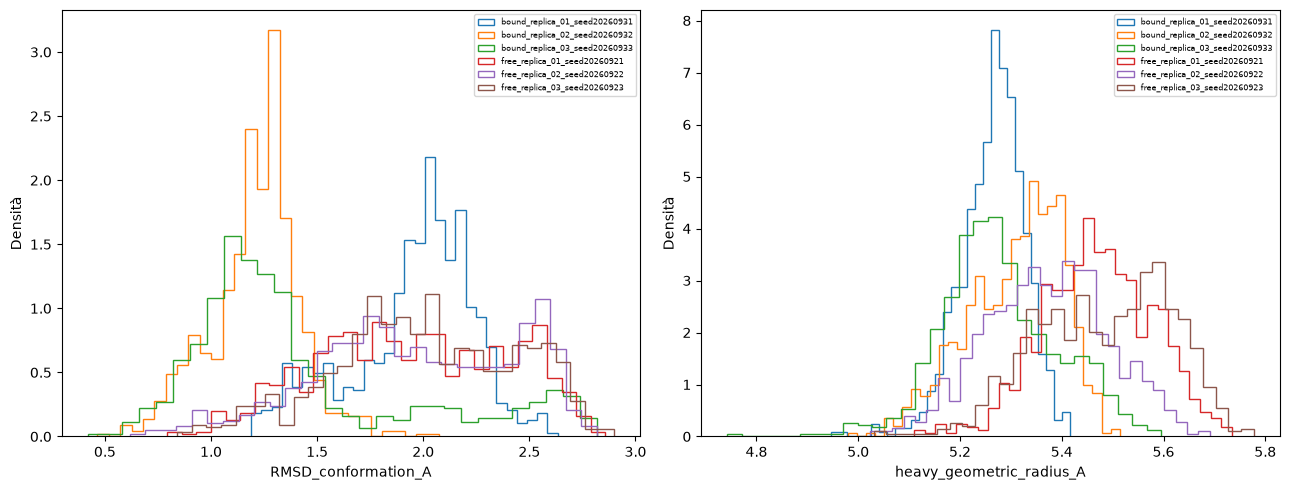

RMSD_conformation_A                      \
                                             mean       std       min   
series                                                                  
bound_replica_01_seed20260931            1.951046  0.291397  1.189481   
bound_replica_02_seed20260932            1.211501  0.212620  0.464684   
bound_replica_03_seed20260933            1.412182  0.540824  0.419929   
free_replica_01_seed20260921             1.949504  0.444520  0.793688   
free_replica_02_seed20260922             1.964267  0.467157  0.616030   
free_replica_03_seed20260923             2.001937  0.424316  0.840982   

                                        heavy_geometric_radius_A            \
                                    max                     mean       std   
series                                                                       
bound_replica_01_seed20260931  2.632995                 5.265193  0.062638   
bound_replica_02_seed20260932  2.073839                 5.308831  0.092531   
bound_replica_03_seed20260933  2.816422                 5.277248  0.114336   
free_replica_01_seed20260921   2.858424                 5.469116  0.106575   
free_replica_02_seed20260922   2.818653                 5.371394  0.119716   
free_replica_03_seed20260923   2.899537                 5.482813  0.132445   

                                                   
                                    min       max  
series                                             
bound_replica_01_seed20260931  4.946559  5.416995  
bound_replica_02_seed20260932  4.979922  5.513815  
bound_replica_03_seed20260933  4.742970  5.595453  
free_replica_01_seed20260921   5.109560  5.734198  
free_replica_02_seed20260922   5.022642  5.690849  
free_replica_03_seed20260923   5.030548  5.777231

,replica,mean_temperature_K,mean_density_g_mL,technical_qc_pass,fraction_site_center_within_8A
0,replica_01_seed20260931,300.310564,1.001989,True,1.0
1,replica_02_seed20260932,300.277064,1.001978,True,1.0
2,replica_03_seed20260933,300.321854,1.001981,True,1.0


{
  "candidate": "MOL00583",
  "mode": "exploratory_production",
  "replicas": 3,
  "production_ps_per_replica": 10000.0,
  "technical_qc_pass": true,
  "shared_initial_structure": true,
  "convergence_established": false,
  "experimentally_validated": false,
  "note": "Confronto conformazionale; nessuna energia libera o entropia."
}
Output: C:\Users\Roberto\PEARL\outputs\pipeline_5_09k_bound_replicates\20260914T100036_153833Z


In [4]:
from scipy.spatial.distance import cdist
site_atoms=protein[np.min(cdist(ref.xyz[0,protein],ref.xyz[0,heavy]),axis=1)<0.5]
require(len(site_atoms)>0,'Sito iniziale vuoto.')
site_res=sorted(set(ref.topology.atom(int(i)).residue.index for i in site_atoms))
site_ca=np.array([a.index for a in ref.topology.atoms if a.residue.index in site_res and a.name=='CA'])
rows=[];metrics=[]
for folder in replica_dirs:
    t=mt.load_dcd(str(folder/'solute.dcd'),top=ref.topology)
    require(t.n_frames==round(PRODUCTION_PS/FRAME_PS),'DCD incompleto.')
    molecules=t.topology.find_molecules()
    anchor=max(molecules,key=len)
    t.image_molecules(anchor_molecules=[anchor],inplace=True)
    pairs=np.array([(a.index,b.index) for a,b in t.topology.bonds])
    require(np.isfinite(t.xyz).all() and mt.compute_distances(t,pairs,periodic=False).max()<0.3,'Coordinate/PBC/legami non validi.')
    rg=np.sqrt(((t.xyz[:,heavy]-t.xyz[:,heavy].mean(axis=1,keepdims=True))**2).sum(axis=2).mean(axis=1))*10
    conform=mt.rmsd(t,ref,atom_indices=heavy,ref_atom_indices=heavy)*10
    t.superpose(ref,atom_indices=ca)
    protein_rms=np.sqrt(((t.xyz[:,ca]-ref.xyz[0,ca])**2).sum(axis=2).mean(axis=1))*10
    ligand_rms=np.sqrt(((t.xyz[:,heavy]-ref.xyz[0,heavy])**2).sum(axis=2).mean(axis=1))*10
    distance=np.linalg.norm(t.xyz[:,heavy].mean(axis=1)-t.xyz[:,site_atoms].mean(axis=1),axis=1)*10
    table=pd.DataFrame({'time_ps':(np.arange(t.n_frames)+1)*FRAME_PS,'RMSD_conformation_A':conform,
       'heavy_geometric_radius_A':rg,'protein_CA_RMSD_A':protein_rms,'ligand_EGFR_fit_RMSD_A':ligand_rms,
       'site_center_distance_A':distance,'series':folder.name})
    keep=int(t.n_frames*DISCARD_FRACTION);table['included']=np.arange(t.n_frames)>=keep
    table.to_csv(folder/'metrics.csv',index=False);metrics.append(table)
    contacts=[]
    for res in t.topology.residues:
        atoms=[a.index for a in res.atoms if a.index in set(protein)]
        if not atoms:continue
        cp=np.array([(i,j) for i in atoms for j in heavy])
        occ=(mt.compute_distances(t,cp,periodic=False)[keep:].min(axis=1)<0.4).mean()
        if occ>0:contacts.append({'residue_index':res.index,'resSeq':res.resSeq,'name':res.name,'chain_index':res.chain.index,'occupancy':occ})
    pd.DataFrame(contacts).to_csv(folder/'contact_persistence.csv',index=False)
    xyz=t.xyz[keep:,site_ca];rmsf=np.sqrt(((xyz-xyz.mean(axis=0))**2).sum(axis=2).mean(axis=0))*10
    pd.DataFrame({'CA_index':site_ca,'RMSF_A':rmsf}).to_csv(folder/'site_RMSF.csv',index=False)
    log=pd.read_csv(folder/'production.csv').iloc[keep:]
    temp=log[next(x for x in log if 'Temperature' in x)].to_numpy(float)
    density=log[next(x for x in log if 'Density' in x)].to_numpy(float)
    ok=bool(np.isfinite(temp).all() and np.isfinite(density).all() and abs(temp.mean()-300)<5 and 0.95<density.mean()<1.05)
    rows.append({'replica':folder.name,'mean_temperature_K':temp.mean(),'mean_density_g_mL':density.mean(),
        'technical_qc_pass':ok,'fraction_site_center_within_8A':float((distance[keep:]<8).mean())})
bound=pd.concat(metrics,ignore_index=True);bound.to_csv(RUN/'bound_metrics.csv',index=False)
free=pd.read_csv(FREE_RUN/'free_bound_metrics.csv');free=free[free.series!='bound_09h_1ns'].copy()
free['series']='free_'+free.series
compare=bound.copy();compare['series']='bound_'+compare.series
compare=pd.concat([compare,free],ignore_index=True);compare=compare[compare.included==True]
compare.to_csv(RUN/'free_bound_comparison.csv',index=False)
cols=['RMSD_conformation_A','heavy_geometric_radius_A']
stats=compare.groupby('series')[cols].agg(['mean','std','min','max']);stats.to_csv(RUN/'comparison_summary.csv')
fig,axes=plt.subplots(1,2,figsize=(13,5))
for name,g in compare.groupby('series'):
    for ax,col in zip(axes,cols):ax.hist(g[col],bins=30,histtype='step',density=True,label=name)
for ax,col in zip(axes,cols):ax.set_xlabel(col);ax.set_ylabel('Densità');ax.legend(fontsize=6)
fig.tight_layout();fig.savefig(RUN/'comparison.png',dpi=220);plt.show()
qc=pd.DataFrame(rows);qc.to_csv(RUN/'QC.csv',index=False)
summary={'candidate':'MOL00583','mode':'smoke_test' if FAST_TEST_MODE else 'exploratory_production',
 'replicas':len(SEEDS),'production_ps_per_replica':PRODUCTION_PS,'technical_qc_pass':bool(qc.technical_qc_pass.all()),
 'shared_initial_structure':True,'convergence_established':False,'experimentally_validated':False,
 'note':'Confronto conformazionale; nessuna energia libera o entropia.'}
dump(RUN/'09k_summary.json',summary);provenance.update(status='completed',summary=summary);dump(RUN/'provenance.json',provenance)
display(stats);display(qc);print(json.dumps(summary,indent=2));print('Output:',RUN)
